# Livrable Final - Modélisation, Implémentation et Exploitation

Ce notebook a été restructuré pour couvrir l'ensemble des attentes du livrable final :

- modélisation formelle du problème ;
- analyse de complexité ;
- génération d'instances aléatoires justifiée ;
- résolution par au moins deux méthodes différentes ;
- démonstration sur plusieurs cas de test ;
- étude expérimentale reproductible et interprétable.

Le problème retenu est un **CVRP** (*Capacitated Vehicle Routing Problem*) : plusieurs véhicules partent d'un dépôt, livrent un ensemble de clients et reviennent au dépôt, tout en respectant la capacité maximale des véhicules.

### Contexte Métier : Réponse à l'Appel à Manifestation d'Intérêt de l'ADEME

Dans le cadre de la transition écologique, l’**ADEME** a lancé un appel à projets visant à optimiser la logistique des transports pour réduire l'empreinte carbone et la consommation énergétique. En tant qu'équipe au sein de **CesiCDP**, spécialisée dans la Mobilité Multimodale Intelligente, notre objectif à travers ce notebook est de fournir un **démonstrateur algorithmique** robuste.

Les applications directes de cette étude sont nombreuses : optimisation des livraisons du dernier kilomètre, ramassage des ordures, ou distribution de courrier. 
Pour répondre à ce défi, nous avons modélisé le problème sous la forme d'un **CVRP (Capacitated Vehicle Routing Problem)**. Ce modèle mathématique permet d'allouer intelligemment une flotte de plusieurs véhicules disposant de capacités limitées, garantissant ainsi que nos algorithmes proposent des tournées réalistes, évitant les trajets à vide et minimisant la distance totale parcourue (et par extension, les émissions de gaz à effet de serre).

## 1. Cadrage du problème et contraintes retenues

Nous modélisons la livraison de marchandises sur un territoire à l'aide d'un graphe complet pondéré. Les deux contraintes métiers retenues sont :

- **l'utilisation de plusieurs véhicules** : la solution est composée de plusieurs sous-tournées au départ du même dépôt ;
- **la capacité maximale des véhicules** : chaque tournée doit rester compatible avec la charge utile disponible.

Ces choix sont cohérents avec l'énoncé ADEME : ils représentent une situation réaliste de logistique urbaine ou périurbaine, tout en restant suffisamment génériques pour permettre une étude algorithmique complète.

Dans ce notebook, nous comparerons deux familles de méthodes constructives :

1. une heuristique **Sweep + Plus Proche Voisin** ;
2. l'heuristique des **Savings de Clarke & Wright**.

Nous ajouterons également une amélioration locale **2-opt** pour montrer l'impact d'une phase d'optimisation après construction.

## 2. Modélisation formelle

On considère un graphe complet pondéré :

- $G = (V, E)$ avec $V = \{0\} \cup C$ ;
- le sommet $0$ représente le **dépôt** ;
- $C = \{1, 2, \dots, n\}$ représente l'ensemble des **clients** ;
- pour tout couple $(i, j)$ de sommets distincts, l'arête $(i, j)$ appartient à $E$ ;
- $c_{ij} \ge 0$ est le coût de déplacement de $i$ vers $j$.

Chaque client $i \in C$ possède une demande $q_i > 0$. Tous les véhicules sont supposés homogènes et de capacité maximale $Q$.

Une solution est un ensemble de tournées $R = \{r_1, r_2, \dots, r_m\}$ tel que chaque tournée :

- commence au dépôt ;
- visite un sous-ensemble de clients ;
- revient au dépôt.

On note une tournée sous la forme $r = (0, v_1, v_2, \dots, v_p, 0)$.

### Fonction objectif

Minimiser le coût total parcouru :

$$\min \sum_{r \in R} \sum_{h=0}^{|r|-2} c_{r_h, r_{h+1}}$$

### Contraintes

1. **Visite unique** : chaque client est visité une et une seule fois.

$$\forall i \in C,\quad \sum_{r \in R} \mathbf{1}_{\{i \in r\}} = 1$$

2. **Capacité** : la demande totale transportée sur une tournée ne dépasse pas $Q$.

$$\forall r \in R,\quad \sum_{i \in r \cap C} q_i \le Q$$

3. **Structure des tournées** : chaque tournée part du dépôt et y revient.

$$\forall r \in R,\quad r_0 = 0 \text{ et } r_{|r|-1} = 0$$

4. **Multi-véhicules** : le nombre de véhicules utilisés est $m = |R|$.

Dans notre implémentation, ce nombre n'est pas fixé a priori ; il est induit par les contraintes de capacité. Si l'on souhaite imposer une taille de flotte maximale $K_{\max}$, il suffit d'ajouter la contrainte $|R| \le K_{\max}$.

### Hypothèses de génération

- le graphe est **complet** ;
- les coûts sont des **distances euclidiennes** entre coordonnées 2D ;
- le dépôt est placé au centre de la zone ;
- les clients sont distribués soit uniformément, soit en grappes (*clustered*) afin de simuler différents types de territoires.

## 3. Analyse de complexité

Le problème traité est une variante du **Vehicle Routing Problem** avec capacité. Il généralise le **TSP** : si la capacité est suffisamment grande pour tout transporter avec un seul véhicule, on retrouve un problème de tournée unique.

Comme le TSP est NP-difficile, le CVRP est lui aussi **NP-difficile**. En pratique, cela signifie qu'une résolution exacte devient rapidement coûteuse quand le nombre de clients augmente.

### Complexité des méthodes utilisées

- **Génération d'instance** : le calcul de la matrice des distances coûte $O(n^2)$.
- **Sweep + Plus Proche Voisin** : tri angulaire en $O(n \log n)$ puis construction de routes. Avec l'évaluation de plusieurs rotations, on reste en pratique autour de $O(n^3)$.
- **Clarke & Wright Savings** : le calcul des savings est en $O(n^2)$ et leur tri en $O(n^2 \log n)$.
- **Amélioration locale (2-opt) :** La recherche d'une amélioration au sein d'une tournée de longueur $p$ nécessite d'évaluer toutes les paires d'arêtes, soit une complexité de $O(p^2)$ par itération. La complexité globale dépend du nombre d'itérations nécessaires pour atteindre un optimum local, mais reste polynomiale en pratique.

### Conséquence pour le projet

Une résolution exacte n'est pas le meilleur choix pour un démonstrateur devant produire rapidement des solutions sur des tailles moyennes. Nous privilégions donc des **heuristiques** et **métaheuristiques légères**, capables de fournir de bonnes solutions dans des temps faibles.

### 3.1 Démonstration formelle de la NP-difficulté (Réduction du TSP au CVRP)

Le problème du voyageur de commerce (TSP) est un problème d'optimisation classique connu pour être NP-difficile. 
Nous pouvons démontrer que le CVRP est au moins aussi difficile que le TSP par une réduction polynomiale ($TSP \leq_p CVRP$).

**Preuve par réduction :**
Soit une instance quelconque du TSP définie par un graphe complet $G=(V, E)$ et une matrice de coûts $c_{ij}$.
Construisons une instance du CVRP à partir de cette instance TSP en un temps polynomial :
1. Fixons un sommet arbitraire $v_0 \in V$ comme le dépôt de notre flotte.
2. Attribuons à chaque autre sommet $v_i$ (représentant nos clients) une demande unitaire $q_i = 1$.
3. Fixons la flotte à un seul véhicule ($K=1$) disposant d'une capacité $Q$ supérieure ou égale au nombre total de clients ($Q \ge |V| - 1$).

Dans cette configuration spécifique, la contrainte de capacité $Q$ ne sera jamais violée. Le problème consiste alors à minimiser le coût d'une tournée unique passant par tous les clients et revenant au dépôt. Cela correspond exactement à la définition mathématique de la recherche d'un cycle hamiltonien de coût minimum : le TSP.
Puisque nous pouvons résoudre n'importe quelle instance du TSP si nous disposons d'un algorithme exact pour le CVRP, le CVRP est intrinsèquement **NP-difficile**.

## 4. Paramètres des instances et protocole expérimental

### Paramètres de génération retenus

- **Nombre de clients** : variable selon les scénarios pour observer le passage à l'échelle.
- **Coordonnées** : zone carrée de taille `100 x 100`.
- **Demandes** : entiers aléatoires dans un intervalle fixé, par défaut entre `1` et `10`.
- **Capacité** : calculée à partir de la demande totale et d'un paramètre de tension `capacity_tightness`.
- **Distribution spatiale** :
  - `uniform` : clients dispersés de manière homogène ;
  - `clustered` : clients regroupés en zones denses, ce qui simule davantage une ville structurée en quartiers.

### Métriques observées

- **coût total** de la solution ;
- **nombre de véhicules** utilisés ;
- **temps d'exécution** ;
- **écart relatif au meilleur solveur** sur la même instance.

L'objectif n'est pas seulement de savoir quel algorithme est le meilleur, mais de comprendre **dans quels contextes** il devient intéressant.

In [1]:
from dataclasses import dataclass
from statistics import mean, stdev
from typing import Callable, Dict, List, Optional, Sequence, Tuple
import math
import random
import time

try:
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-whitegrid')
    HAS_MATPLOTLIB = True
except Exception:
    plt = None
    HAS_MATPLOTLIB = False
    print('matplotlib indisponible : les graphiques seront ignorés.')


@dataclass
class CVRPInstance:
    coords: List[Tuple[float, float]]
    demands: List[int]
    capacity: int
    distance_matrix: List[List[float]]
    distribution: str
    seed: Optional[int] = None

    @property
    def num_clients(self) -> int:
        return len(self.demands) - 1


def euclidean_distance(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    return math.hypot(a[0] - b[0], a[1] - b[1])


def compute_distance_matrix(coords: Sequence[Tuple[float, float]]) -> List[List[float]]:
    n = len(coords)
    matrix = [[0.0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            distance = euclidean_distance(coords[i], coords[j])
            matrix[i][j] = distance
            matrix[j][i] = distance
    return matrix


def generate_coordinates(
    rng: random.Random,
    num_clients: int,
    grid_size: int = 100,
    distribution: str = 'uniform',
) -> List[Tuple[float, float]]:
    depot = (grid_size / 2, grid_size / 2)
    coords = [depot]

    if distribution == 'uniform':
        for _ in range(num_clients):
            coords.append((rng.uniform(0, grid_size), rng.uniform(0, grid_size)))
        return coords

    if distribution == 'clustered':
        centers = [
            (rng.uniform(0.2 * grid_size, 0.8 * grid_size), rng.uniform(0.2 * grid_size, 0.8 * grid_size))
            for _ in range(3)
        ]
        sigma = grid_size / 10
        for _ in range(num_clients):
            cx, cy = rng.choice(centers)
            x = min(grid_size, max(0.0, rng.gauss(cx, sigma)))
            y = min(grid_size, max(0.0, rng.gauss(cy, sigma)))
            coords.append((x, y))
        return coords

    raise ValueError("distribution doit valoir 'uniform' ou 'clustered'")


def generate_cvrp_instance(
    num_clients: int = 20,
    grid_size: int = 100,
    demand_range: Tuple[int, int] = (1, 10),
    capacity_tightness: float = 1.15,
    distribution: str = 'uniform',
    seed: Optional[int] = None,
) -> CVRPInstance:
    rng = random.Random(seed)
    coords = generate_coordinates(rng, num_clients, grid_size, distribution)
    demands = [0] + [rng.randint(demand_range[0], demand_range[1]) for _ in range(num_clients)]
    total_demand = sum(demands)

    target_routes = max(2, math.ceil(num_clients / 6))
    base_capacity = math.ceil(total_demand / target_routes)
    capacity = max(max(demands), math.ceil(base_capacity * capacity_tightness))

    distance_matrix = compute_distance_matrix(coords)
    return CVRPInstance(
        coords=coords,
        demands=demands,
        capacity=capacity,
        distance_matrix=distance_matrix,
        distribution=distribution,
        seed=seed,
    )


def route_load(route: Sequence[int], demands: Sequence[int]) -> int:
    return sum(demands[node] for node in route if node != 0)


def route_cost(route: Sequence[int], distance_matrix: Sequence[Sequence[float]]) -> float:
    return sum(distance_matrix[route[i]][route[i + 1]] for i in range(len(route) - 1))


def solution_cost(routes: Sequence[Sequence[int]], distance_matrix: Sequence[Sequence[float]]) -> float:
    return sum(route_cost(route, distance_matrix) for route in routes)


def describe_instance(instance: CVRPInstance) -> str:
    return (
        f"{instance.num_clients} clients | distribution={instance.distribution} | "
        f"demande totale={sum(instance.demands)} | capacité={instance.capacity}"
    )


def validate_solution(instance: CVRPInstance, routes: Sequence[Sequence[int]]) -> Dict[str, object]:
    expected_clients = set(range(1, instance.num_clients + 1))
    seen_clients: List[int] = []
    messages: List[str] = []

    for route_index, route in enumerate(routes, start=1):
        if len(route) < 2 or route[0] != 0 or route[-1] != 0:
            messages.append(f'Tournée {route_index} invalide : elle doit partir du dépôt et y revenir.')
        load = route_load(route, instance.demands)
        if load > instance.capacity:
            messages.append(
                f'Tournée {route_index} invalide : charge {load} > capacité {instance.capacity}.'
            )
        seen_clients.extend(node for node in route[1:-1])

    seen_set = set(seen_clients)
    missing = sorted(expected_clients - seen_set)
    duplicates = len(seen_clients) != len(seen_set)
    extras = sorted(seen_set - expected_clients)

    if missing:
        messages.append(f'Clients non servis : {missing}')
    if duplicates:
        messages.append('Certains clients sont visités plusieurs fois.')
    if extras:
        messages.append(f'Clients inattendus dans la solution : {extras}')

    return {
        'valid': len(messages) == 0,
        'messages': messages,
    }


def plot_instance(instance: CVRPInstance, ax=None, title: str = 'Instance'):
    if not HAS_MATPLOTLIB:
        print(f'[Graphique ignoré] {title}')
        return

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    depot_x, depot_y = instance.coords[0]
    client_x = [x for x, _ in instance.coords[1:]]
    client_y = [y for _, y in instance.coords[1:]]

    ax.scatter(client_x, client_y, s=40, color='#2f6f9f', label='Clients')
    ax.scatter([depot_x], [depot_y], s=150, marker='s', color='#d1495b', label='Dépôt')

    if instance.num_clients <= 25:
        for client in range(1, instance.num_clients + 1):
            x, y = instance.coords[client]
            ax.text(x + 1, y + 1, str(client), fontsize=8)

    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='best')


def plot_solution(instance: CVRPInstance, routes: Sequence[Sequence[int]], ax=None, title: str = 'Solution'):
    if not HAS_MATPLOTLIB:
        print(f'[Graphique ignoré] {title}')
        return

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    plot_instance(instance, ax=ax, title=title)
    colors = plt.cm.tab20.colors

    for route_index, route in enumerate(routes):
        color = colors[route_index % len(colors)]
        xs = [instance.coords[node][0] for node in route]
        ys = [instance.coords[node][1] for node in route]
        label = f'Vehicule {route_index + 1} (charge={route_load(route, instance.demands)})'
        ax.plot(xs, ys, color=color, linewidth=2, marker='o', alpha=0.9, label=label)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=8, loc='best')


## 5. Méthode 1 - Sweep + Plus Proche Voisin 

Cette première méthode est volontairement simple et rapide. Elle est appelée en anglais "Sweep + NN" couramment pour "Nearest Neighbor", dans un soucis de facilité, nous adopterons ce raccourci lorsque nous le citerons.

### Idée

1. On trie les clients selon leur angle autour du dépôt (**sweep**).
2. On découpe cette liste en groupes compatibles avec la capacité du véhicule.
3. À l'intérieur de chaque groupe, on construit l'ordre de visite par **plus proche voisin**.

Cette approche est cohérente avec un usage multi-véhicules : on forme d'abord des zones de service, puis on ordonne chaque tournée.

### Limites

- le choix des groupes dépend fortement de l'ordre angulaire ;
- le plus proche voisin est glouton et peut produire des croisements ou des retours inefficaces.

In [2]:
def angle_sorted_clients(instance: CVRPInstance) -> List[int]:
    depot_x, depot_y = instance.coords[0]
    clients = list(range(1, instance.num_clients + 1))
    return sorted(
        clients,
        key=lambda client: math.atan2(
            instance.coords[client][1] - depot_y,
            instance.coords[client][0] - depot_x,
        ),
    )


def split_by_capacity(sequence: Sequence[int], demands: Sequence[int], capacity: int) -> List[List[int]]:
    routes: List[List[int]] = []
    current_route: List[int] = []
    current_load = 0

    for client in sequence:
        demand = demands[client]
        if current_route and current_load + demand > capacity:
            routes.append(current_route)
            current_route = []
            current_load = 0

        current_route.append(client)
        current_load += demand

    if current_route:
        routes.append(current_route)

    return routes


def nearest_neighbor_route(clients: Sequence[int], distance_matrix: Sequence[Sequence[float]]) -> List[int]:
    unvisited = set(clients)
    route = [0]
    current = 0

    while unvisited:
        next_client = min(unvisited, key=lambda client: distance_matrix[current][client])
        route.append(next_client)
        unvisited.remove(next_client)
        current = next_client

    route.append(0)
    return route


def solve_sweep_nn(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    ordered_clients = angle_sorted_clients(instance)

    if not ordered_clients:
        return [[0, 0]], 0.0

    best_routes: Optional[List[List[int]]] = None
    best_cost = float('inf')

    for shift in range(len(ordered_clients)):
        rotated = ordered_clients[shift:] + ordered_clients[:shift]
        groups = split_by_capacity(rotated, instance.demands, instance.capacity)
        routes = [nearest_neighbor_route(group, instance.distance_matrix) for group in groups]
        total = solution_cost(routes, instance.distance_matrix)

        if total < best_cost:
            best_cost = total
            best_routes = routes

    if best_routes is None:
        raise RuntimeError('Impossible de construire une solution Sweep + NN.')

    return best_routes, best_cost


def two_opt_route(route: Sequence[int], distance_matrix: Sequence[Sequence[float]]) -> List[int]:
    best_route = list(route)
    improved = True

    while improved:
        improved = False
        best_delta = 0.0
        best_i = None
        best_j = None

        for i in range(1, len(best_route) - 2):
            for j in range(i + 1, len(best_route) - 1):
                if j - i == 1:
                    continue

                current_edges = (
                    distance_matrix[best_route[i - 1]][best_route[i]]
                    + distance_matrix[best_route[j]][best_route[j + 1]]
                )
                new_edges = (
                    distance_matrix[best_route[i - 1]][best_route[j]]
                    + distance_matrix[best_route[i]][best_route[j + 1]]
                )
                delta = new_edges - current_edges

                if delta < best_delta - 1e-12:
                    best_delta = delta
                    best_i = i
                    best_j = j

        if best_i is not None and best_j is not None:
            best_route[best_i:best_j + 1] = reversed(best_route[best_i:best_j + 1])
            improved = True

    return best_route


def improve_solution_2opt(routes: Sequence[Sequence[int]], instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    improved_routes = [two_opt_route(route, instance.distance_matrix) for route in routes]
    return improved_routes, solution_cost(improved_routes, instance.distance_matrix)


def solve_sweep_nn_2opt(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    routes, _ = solve_sweep_nn(instance)
    return improve_solution_2opt(routes, instance)


## 6. Méthode 2 - Clarke & Wright Savings

L'heuristique des savings démarre avec une solution triviale où chaque client est desservi par un véhicule dédié : `(0, i, 0)`.

Pour deux clients $i$ et $j$, le **gain** à les mettre dans une même tournée vaut :

$$s_{ij} = c_{0i} + c_{0j} - c_{ij}$$

Plus ce gain est élevé, plus il est intéressant d'essayer de fusionner les deux tournées, à condition de rester compatible avec la capacité.

### Intérêt de cette méthode

- elle exploite directement la structure du coût ;
- elle produit souvent de meilleures solutions que les heuristiques purement gloutonnes ;
- elle reste très rapide sur des tailles moyennes.

Nous testons également une version **Clarke & Wright + 2-opt** pour voir si une amélioration locale apporte un gain supplémentaire.

### Extension par métaheuristiques

À partir de la meilleure solution constructive disponible, nous ajoutons ensuite deux métaheuristiques de recherche :

- **Recuit simulé** : accepte parfois une solution moins bonne pour éviter de rester bloqué dans un optimum local ;
- **Recherche tabou** : explore un voisinage de solutions tout en mémorisant temporairement des états interdits pour diversifier la recherche.

Dans les deux cas, les mouvements autorisés respectent la contrainte de capacité et manipulent directement les tournées : déplacement d'un client, échange de clients entre tournées, ou réordonnancement interne.

In [3]:
def merge_routes_if_possible(
    route_a: Sequence[int],
    route_b: Sequence[int],
    client_i: int,
    client_j: int,
) -> Optional[List[int]]:
    body_a = list(route_a[1:-1])
    body_b = list(route_b[1:-1])

    if not body_a or not body_b:
        return None

    if body_a[-1] == client_i and body_b[0] == client_j:
        return [0] + body_a + body_b + [0]

    if body_a[0] == client_i and body_b[-1] == client_j:
        return [0] + list(reversed(body_a)) + list(reversed(body_b)) + [0]

    if body_a[-1] == client_i and body_b[-1] == client_j:
        return [0] + body_a + list(reversed(body_b)) + [0]

    if body_a[0] == client_i and body_b[0] == client_j:
        return [0] + list(reversed(body_a)) + body_b + [0]

    return None


def solve_clarke_wright(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    n = instance.num_clients
    dist = instance.distance_matrix
    demands = instance.demands

    routes: Dict[int, List[int]] = {client: [0, client, 0] for client in range(1, n + 1)}
    route_loads: Dict[int, int] = {client: demands[client] for client in range(1, n + 1)}
    client_to_route: Dict[int, int] = {client: client for client in range(1, n + 1)}

    savings: List[Tuple[float, int, int]] = []
    for i in range(1, n + 1):
        for j in range(i + 1, n + 1):
            saving = dist[0][i] + dist[0][j] - dist[i][j]
            savings.append((saving, i, j))

    savings.sort(reverse=True)

    for _, i, j in savings:
        route_i_id = client_to_route[i]
        route_j_id = client_to_route[j]

        if route_i_id == route_j_id:
            continue

        route_i = routes[route_i_id]
        route_j = routes[route_j_id]

        if route_loads[route_i_id] + route_loads[route_j_id] > instance.capacity:
            continue

        merged = merge_routes_if_possible(route_i, route_j, i, j)
        if merged is None:
            continue

        routes[route_i_id] = merged
        route_loads[route_i_id] = route_loads[route_i_id] + route_loads[route_j_id]

        for client in merged[1:-1]:
            client_to_route[client] = route_i_id

        del routes[route_j_id]
        del route_loads[route_j_id]

    final_routes = sorted(routes.values(), key=lambda route: route[1] if len(route) > 2 else 0)
    total = solution_cost(final_routes, dist)
    return final_routes, total


def solve_clarke_wright_2opt(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    routes, _ = solve_clarke_wright(instance)
    return improve_solution_2opt(routes, instance)


def clone_routes(routes: Sequence[Sequence[int]]) -> List[List[int]]:
    return [list(route) for route in routes if len(route) > 2]


def canonical_route(route: Sequence[int]) -> Tuple[int, ...]:
    body = tuple(route[1:-1])
    reverse_body = tuple(reversed(body))
    return body if body <= reverse_body else reverse_body


def solution_signature(routes: Sequence[Sequence[int]]) -> Tuple[Tuple[int, ...], ...]:
    return tuple(sorted(canonical_route(route) for route in routes if len(route) > 2))


def best_constructive_solution(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    candidates = [solve_sweep_nn_2opt(instance), solve_clarke_wright_2opt(instance)]
    best_routes, best_cost = min(candidates, key=lambda item: item[1])
    return clone_routes(best_routes), best_cost


def optimize_selected_routes(
    routes: List[List[int]],
    route_indexes: Sequence[int],
    instance: CVRPInstance,
) -> List[List[int]]:
    optimized = clone_routes(routes)
    for idx in sorted(set(route_indexes)):
        if 0 <= idx < len(optimized) and len(optimized[idx]) >= 5:
            optimized[idx] = two_opt_route(optimized[idx], instance.distance_matrix)
    return optimized


def random_relocate_neighbor(
    current_routes: Sequence[Sequence[int]],
    instance: CVRPInstance,
    rng: random.Random,
) -> Optional[Tuple[List[List[int]], Tuple[object, ...]]]:
    routes = clone_routes(current_routes)
    if not routes:
        return None

    for _ in range(40):
        source_idx = rng.randrange(len(routes))
        source_route = routes[source_idx]
        if len(source_route) <= 2:
            continue

        source_pos = rng.randint(1, len(source_route) - 2)
        client = source_route[source_pos]
        demand = instance.demands[client]

        target_choices: List[object] = [idx for idx in range(len(routes)) if idx != source_idx]
        if len(source_route) > 3:
            target_choices.append('new')
        if not target_choices:
            continue

        target_choice = rng.choice(target_choices)
        new_routes = clone_routes(routes)
        new_routes[source_idx].pop(source_pos)
        source_removed = len(new_routes[source_idx]) == 2

        if source_removed:
            del new_routes[source_idx]

        affected: List[int] = []
        if not source_removed:
            affected.append(source_idx)

        if target_choice == 'new':
            new_routes.append([0, client, 0])
            affected.append(len(new_routes) - 1)
        else:
            target_idx = int(target_choice)
            if source_removed and target_idx > source_idx:
                target_idx -= 1
            if route_load(new_routes[target_idx], instance.demands) + demand > instance.capacity:
                continue
            insert_pos = rng.randint(1, len(new_routes[target_idx]) - 1)
            new_routes[target_idx].insert(insert_pos, client)
            affected.append(target_idx)

        new_routes = optimize_selected_routes(new_routes, affected, instance)
        if solution_signature(new_routes) == solution_signature(current_routes):
            continue
        return new_routes, ('relocate', client)

    return None


def random_swap_neighbor(
    current_routes: Sequence[Sequence[int]],
    instance: CVRPInstance,
    rng: random.Random,
) -> Optional[Tuple[List[List[int]], Tuple[object, ...]]]:
    routes = clone_routes(current_routes)
    if len(routes) < 2:
        return None

    for _ in range(40):
        route_a_idx, route_b_idx = rng.sample(range(len(routes)), 2)
        route_a = routes[route_a_idx]
        route_b = routes[route_b_idx]
        if len(route_a) <= 2 or len(route_b) <= 2:
            continue

        pos_a = rng.randint(1, len(route_a) - 2)
        pos_b = rng.randint(1, len(route_b) - 2)
        client_a = route_a[pos_a]
        client_b = route_b[pos_b]
        demand_a = instance.demands[client_a]
        demand_b = instance.demands[client_b]

        load_a = route_load(route_a, instance.demands)
        load_b = route_load(route_b, instance.demands)
        if load_a - demand_a + demand_b > instance.capacity:
            continue
        if load_b - demand_b + demand_a > instance.capacity:
            continue

        new_routes = clone_routes(routes)
        new_routes[route_a_idx][pos_a] = client_b
        new_routes[route_b_idx][pos_b] = client_a
        new_routes = optimize_selected_routes(new_routes, [route_a_idx, route_b_idx], instance)

        if solution_signature(new_routes) == solution_signature(current_routes):
            continue
        return new_routes, ('swap', client_a, client_b)

    return None


def random_intra_route_neighbor(
    current_routes: Sequence[Sequence[int]],
    instance: CVRPInstance,
    rng: random.Random,
) -> Optional[Tuple[List[List[int]], Tuple[object, ...]]]:
    routes = clone_routes(current_routes)
    candidates = [idx for idx, route in enumerate(routes) if len(route) >= 5]
    if not candidates:
        return None

    for _ in range(40):
        route_idx = rng.choice(candidates)
        route = routes[route_idx]
        new_routes = clone_routes(routes)

        i = rng.randint(1, len(route) - 3)
        j = rng.randint(i + 1, len(route) - 2)
        if j - i >= 2:
            new_routes[route_idx][i:j + 1] = reversed(new_routes[route_idx][i:j + 1])
        else:
            new_routes[route_idx][i], new_routes[route_idx][j] = new_routes[route_idx][j], new_routes[route_idx][i]

        if rng.random() < 0.5:
            new_routes = optimize_selected_routes(new_routes, [route_idx], instance)

        if solution_signature(new_routes) == solution_signature(current_routes):
            continue
        return new_routes, ('reorder', route_idx)

    return None


def generate_random_neighbor(
    current_routes: Sequence[Sequence[int]],
    instance: CVRPInstance,
    rng: random.Random,
) -> Optional[Tuple[List[List[int]], Tuple[object, ...]]]:
    operators = [random_relocate_neighbor, random_swap_neighbor, random_intra_route_neighbor]
    weights = [0.45, 0.30, 0.25]

    for _ in range(50):
        operator = rng.choices(operators, weights=weights, k=1)[0]
        candidate = operator(current_routes, instance, rng)
        if candidate is not None:
            return candidate

    return None


def solve_simulated_annealing(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    rng = random.Random((instance.seed or 0) + 7001)
    current_routes, current_cost = best_constructive_solution(instance)
    best_routes = clone_routes(current_routes)
    best_cost = current_cost

    iterations = max(800, 35 * instance.num_clients)
    initial_temperature = max(1.0, 0.08 * current_cost)
    final_temperature = 1e-3
    cooling = (final_temperature / initial_temperature) ** (1 / max(iterations - 1, 1))
    temperature = initial_temperature

    for _ in range(iterations):
        candidate = generate_random_neighbor(current_routes, instance, rng)
        if candidate is None:
            break

        candidate_routes, _ = candidate
        candidate_cost = solution_cost(candidate_routes, instance.distance_matrix)
        delta = candidate_cost - current_cost

        if delta < 0 or rng.random() < math.exp(-delta / max(temperature, 1e-9)):
            current_routes = candidate_routes
            current_cost = candidate_cost
            if current_cost < best_cost - 1e-9:
                best_routes = clone_routes(current_routes)
                best_cost = current_cost

        temperature *= cooling

    best_routes, best_cost = improve_solution_2opt(best_routes, instance)
    return best_routes, best_cost


def solve_tabu_search(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    rng = random.Random((instance.seed or 0) + 8001)
    current_routes, current_cost = best_constructive_solution(instance)
    best_routes = clone_routes(current_routes)
    best_cost = current_cost

    iterations = max(100, 8 * instance.num_clients)
    neighbors_per_iteration = max(12, min(28, 8 + instance.num_clients // 4))
    tabu_tenure = max(6, min(20, 4 + instance.num_clients // 10))
    tabu_until: Dict[Tuple[Tuple[int, ...], ...], int] = {}
    tabu_until[solution_signature(current_routes)] = tabu_tenure

    for iteration in range(iterations):
        best_candidate = None

        for _ in range(neighbors_per_iteration):
            candidate = generate_random_neighbor(current_routes, instance, rng)
            if candidate is None:
                continue

            candidate_routes, move = candidate
            candidate_cost = solution_cost(candidate_routes, instance.distance_matrix)
            signature = solution_signature(candidate_routes)
            is_tabu = tabu_until.get(signature, -1) > iteration

            if is_tabu and candidate_cost >= best_cost - 1e-9:
                continue

            if best_candidate is None or candidate_cost < best_candidate['cost']:
                best_candidate = {
                    'routes': candidate_routes,
                    'cost': candidate_cost,
                    'signature': signature,
                    'move': move,
                }

        if best_candidate is None:
            continue

        current_routes = best_candidate['routes']
        current_cost = best_candidate['cost']
        tabu_until[best_candidate['signature']] = iteration + tabu_tenure

        if current_cost < best_cost - 1e-9:
            best_routes = clone_routes(current_routes)
            best_cost = current_cost

        if iteration % 20 == 0:
            tabu_until = {signature: expiry for signature, expiry in tabu_until.items() if expiry > iteration}

    best_routes, best_cost = improve_solution_2opt(best_routes, instance)
    return best_routes, best_cost


SOLVERS: Dict[str, Callable[[CVRPInstance], Tuple[List[List[int]], float]]] = {
    'Sweep + NN': solve_sweep_nn,
    'Sweep + NN + 2-opt': solve_sweep_nn_2opt,
    'Clarke-Wright': solve_clarke_wright,
    'Clarke-Wright + 2-opt': solve_clarke_wright_2opt,
    'Recuit simulé': solve_simulated_annealing,
    'Recherche tabou': solve_tabu_search,
}


def benchmark_instance(
    instance: CVRPInstance,
    solvers: Dict[str, Callable[[CVRPInstance], Tuple[List[List[int]], float]]],
) -> List[Dict[str, object]]:
    results: List[Dict[str, object]] = []

    for name, solver in solvers.items():
        start = time.perf_counter()
        try:
            routes, cost = solver(instance)
            elapsed_ms = (time.perf_counter() - start) * 1000
            validation = validate_solution(instance, routes)
            results.append(
                {
                    'solver': name,
                    'routes': routes,
                    'cost': cost,
                    'vehicles': len(routes),
                    'runtime_ms': elapsed_ms,
                    'valid': validation['valid'],
                    'message': '; '.join(validation['messages']) if validation['messages'] else 'OK',
                }
            )
        except Exception as exc:
            elapsed_ms = (time.perf_counter() - start) * 1000
            results.append(
                {
                    'solver': name,
                    'routes': [],
                    'cost': float('inf'),
                    'vehicles': math.inf,
                    'runtime_ms': elapsed_ms,
                    'valid': False,
                    'message': str(exc),
                }
            )

    valid_costs = [result['cost'] for result in results if result['valid'] and math.isfinite(result['cost'])]
    best_cost = min(valid_costs) if valid_costs else float('inf')
    baseline = next((result['cost'] for result in results if result['solver'] == 'Sweep + NN' and result['valid']), float('inf'))

    for result in results:
        if result['valid'] and math.isfinite(best_cost):
            result['gap_to_best_pct'] = 100 * (result['cost'] - best_cost) / best_cost if best_cost > 0 else 0.0
        else:
            result['gap_to_best_pct'] = float('inf')

        if result['valid'] and math.isfinite(baseline) and baseline > 0:
            result['improvement_vs_sweep_pct'] = 100 * (baseline - result['cost']) / baseline
        else:
            result['improvement_vs_sweep_pct'] = float('nan')

    return results


def format_value(value: object) -> str:
    if isinstance(value, float):
        if math.isnan(value):
            return 'nan'
        if math.isinf(value):
            return 'inf'
        return f'{value:.2f}'
    return str(value)


def print_table(rows: Sequence[Dict[str, object]], columns: Sequence[Tuple[str, str]]) -> None:
    if not rows:
        print('Aucune donnée à afficher.')
        return

    widths: List[int] = []
    for key, title in columns:
        width = len(title)
        for row in rows:
            width = max(width, len(format_value(row.get(key, ''))))
        widths.append(width)

    header = ' | '.join(title.ljust(widths[index]) for index, (_, title) in enumerate(columns))
    separator = '-+-'.join('-' * widths[index] for index in range(len(columns)))
    print(header)
    print(separator)

    for row in rows:
        line = ' | '.join(
            format_value(row.get(key, '')).ljust(widths[index])
            for index, (key, _) in enumerate(columns)
        )
        print(line)


## 7. Démonstration sur plusieurs cas de test

Les cellules suivantes permettent de montrer le comportement des solveurs sur deux cas contrastés :

- un territoire **uniforme** ;
- un territoire **clusterisé**.

L'objectif n'est pas d'être exhaustif, mais de vérifier visuellement et numériquement que l'implémentation fonctionne, respecte la capacité et produit des solutions plausibles.


Cas A - territoire uniforme
18 clients | distribution=uniform | demande totale=91 | capacité=35
Solveur               | Coût   | Véhicules | Temps (ms) | Écart % | Gain vs Sweep % | Valide
----------------------+--------+-----------+------------+---------+-----------------+-------
Sweep + NN            | 484.45 | 3         | 0.39       | 4.51    | 0.00            | True  
Sweep + NN + 2-opt    | 471.41 | 3         | 0.40       | 1.69    | 2.69            | True  
Clarke-Wright         | 463.57 | 3         | 0.11       | 0.00    | 4.31            | True  
Clarke-Wright + 2-opt | 463.57 | 3         | 0.11       | 0.00    | 4.31            | True  
Recuit simulé         | 463.57 | 3         | 28.76      | 0.00    | 4.31            | True  
Recherche tabou       | 463.57 | 3         | 71.19      | 0.00    | 4.31            | True  


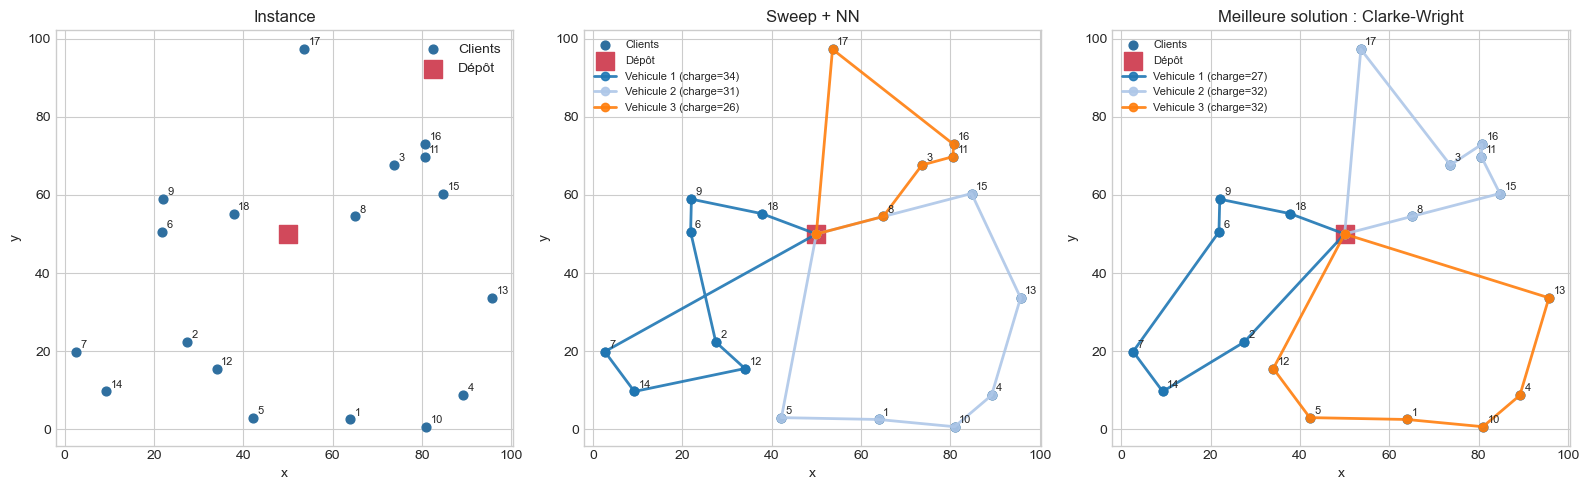


Cas B - territoire clusterisé
18 clients | distribution=clustered | demande totale=101 | capacité=38
Solveur               | Coût   | Véhicules | Temps (ms) | Écart % | Gain vs Sweep % | Valide
----------------------+--------+-----------+------------+---------+-----------------+-------
Sweep + NN            | 280.69 | 3         | 0.49       | 12.54   | 0.00            | True  
Sweep + NN + 2-opt    | 279.88 | 3         | 0.62       | 12.22   | 0.29            | True  
Clarke-Wright         | 249.91 | 3         | 0.18       | 0.20    | 10.96           | True  
Clarke-Wright + 2-opt | 249.91 | 3         | 0.19       | 0.20    | 10.96           | True  
Recuit simulé         | 249.91 | 3         | 31.07      | 0.20    | 10.96           | True  
Recherche tabou       | 249.40 | 3         | 74.79      | 0.00    | 11.15           | True  


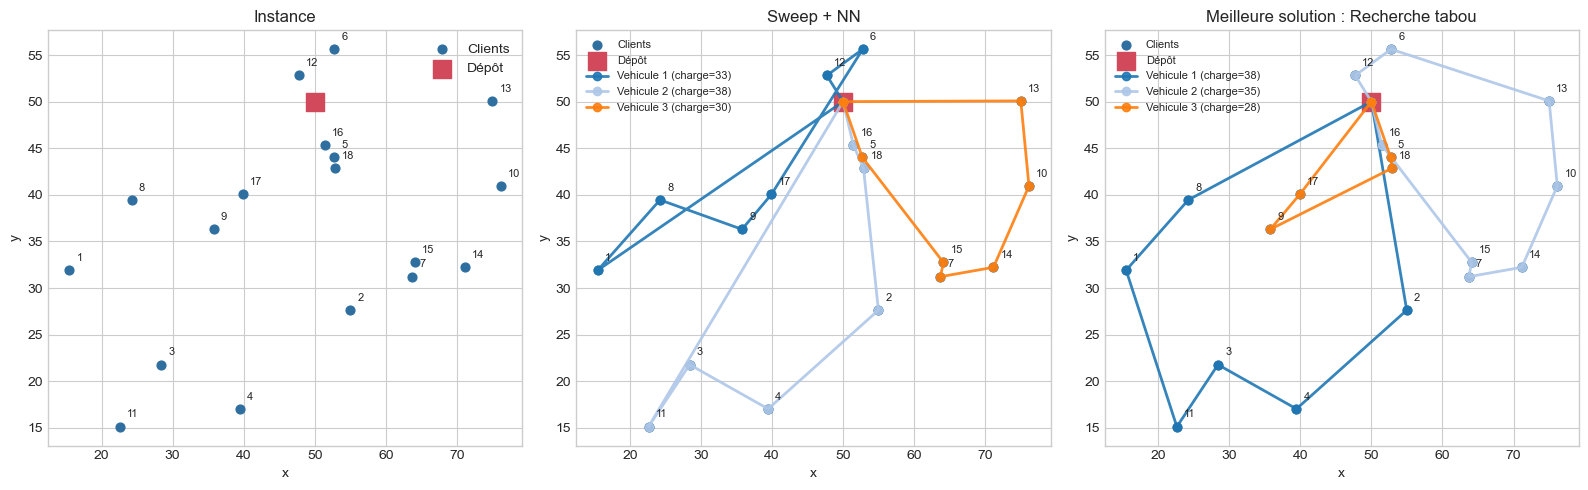

In [4]:
demo_configs = [
    {
        'label': 'Cas A - territoire uniforme',
        'num_clients': 18,
        'distribution': 'uniform',
        'capacity_tightness': 1.10,
        'seed': 42,
    },
    {
        'label': 'Cas B - territoire clusterisé',
        'num_clients': 18,
        'distribution': 'clustered',
        'capacity_tightness': 1.10,
        'seed': 99,
    },
]

for config in demo_configs:
    print('\n' + '=' * 90)
    print(config['label'])

    instance = generate_cvrp_instance(
        num_clients=config['num_clients'],
        distribution=config['distribution'],
        capacity_tightness=config['capacity_tightness'],
        seed=config['seed'],
    )

    print(describe_instance(instance))
    results = benchmark_instance(instance, SOLVERS)

    rows = [
        {
            'solver': result['solver'],
            'cost': result['cost'],
            'vehicles': result['vehicles'],
            'runtime_ms': result['runtime_ms'],
            'gap_to_best_pct': result['gap_to_best_pct'],
            'improvement_vs_sweep_pct': result['improvement_vs_sweep_pct'],
            'valid': result['valid'],
        }
        for result in results
    ]

    print_table(
        rows,
        columns=[
            ('solver', 'Solveur'),
            ('cost', 'Coût'),
            ('vehicles', 'Véhicules'),
            ('runtime_ms', 'Temps (ms)'),
            ('gap_to_best_pct', 'Écart %'),
            ('improvement_vs_sweep_pct', 'Gain vs Sweep %'),
            ('valid', 'Valide'),
        ],
    )

    best_result = min((result for result in results if result['valid']), key=lambda result: result['cost'])
    sweep_result = next(result for result in results if result['solver'] == 'Sweep + NN')

    if HAS_MATPLOTLIB:
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        plot_instance(instance, ax=axes[0], title='Instance')
        plot_solution(instance, sweep_result['routes'], ax=axes[1], title='Sweep + NN')
        plot_solution(instance, best_result['routes'], ax=axes[2], title=f"Meilleure solution : {best_result['solver']}")
        plt.tight_layout()
        plt.show()


### Lecture des figures de démonstration

Sur les figures du **cas A (territoire uniforme)**, on observe que l’heuristique Sweep + Plus Proche Voisin construit des tournées globalement circulaires, mais avec plusieurs détours et croisements qui allongent la distance totale. La meilleure solution (souvent obtenue par Clarke-Wright ou Recherche Tabou) regroupe les clients de manière plus compacte et réduit les allers-retours inutiles vers le dépôt, ce qui se traduit par une baisse du coût de tournée à nombre de véhicules identique.

Dans le **cas B (territoire clusterisé)**, le clustering spatial des clients est beaucoup plus visible : les tournées optimisées exploitent mieux ces “quartiers” en affectant chaque véhicule à un groupe de clients géographiquement proches. On voit que la méthode de base Sweep peut parfois “casser” ces clusters en mélangeant les zones, alors que Clarke-Wright et les métaheuristiques tendent à respecter les regroupements naturels, ce qui améliore la lisibilité des tournées pour un exploitant terrain.


## 8. Étude expérimentale - plan d'expérience

Nous retenons trois facteurs pour l'étude :

1. **taille de l'instance** : nombre de clients `15`, `25`, `35`, `45` ;
2. **structure spatiale** : `uniform` ou `clustered` ;
3. **tension de capacité** : `1.05` (capacité serrée) ou `1.25` (capacité plus confortable).

Chaque combinaison est répétée plusieurs fois avec des graines différentes. On obtient ainsi un plan d'expérience simple, mais suffisamment riche pour discuter :

- de la montée en charge ;
- de la robustesse des solveurs ;
- du compromis qualité / temps d'exécution ;
- de l'effet des contraintes de capacité sur le nombre de véhicules utilisés.

Nous ajoutons ensuite une seconde campagne ciblée sur des tailles **petite, moyenne et grande** (`20`, `50`, `100` clients) afin de montrer explicitement le passage à l'échelle et de justifier que nos algorithmes restent rapides tout en améliorant la qualité des solutions.

In [5]:
def aggregate_stats(values: Sequence[float]) -> Tuple[float, float]:
    if not values:
        return float('nan'), float('nan')
    if len(values) == 1:
        return values[0], 0.0
    return mean(values), stdev(values)


def classify_size(num_clients: int) -> str:
    if num_clients <= 25:
        return 'Petit'
    if num_clients <= 60:
        return 'Moyen'
    return 'Grand'


def summarize_records(records: Sequence[Dict[str, object]], group_keys: Sequence[str]) -> List[Dict[str, object]]:
    buckets: Dict[Tuple[object, ...], Dict[str, List[float]]] = {}

    for record in records:
        if not record['valid']:
            continue

        key = tuple(record[group_key] for group_key in group_keys)
        if key not in buckets:
            buckets[key] = {
                'cost': [],
                'vehicles': [],
                'runtime_ms': [],
                'gap_to_best_pct': [],
                'improvement_vs_sweep_pct': [],
            }

        buckets[key]['cost'].append(record['cost'])
        buckets[key]['vehicles'].append(record['vehicles'])
        buckets[key]['runtime_ms'].append(record['runtime_ms'])
        buckets[key]['gap_to_best_pct'].append(record['gap_to_best_pct'])
        if not math.isnan(record['improvement_vs_sweep_pct']):
            buckets[key]['improvement_vs_sweep_pct'].append(record['improvement_vs_sweep_pct'])

    summary_rows: List[Dict[str, object]] = []
    for key, values in buckets.items():
        row = {group_key: key[index] for index, group_key in enumerate(group_keys)}
        row['instances'] = len(values['cost'])

        for metric_name, metric_values in values.items():
            metric_mean, metric_std = aggregate_stats(metric_values)
            row[f'{metric_name}_mean'] = metric_mean
            row[f'{metric_name}_std'] = metric_std

        summary_rows.append(row)

    return sorted(summary_rows, key=lambda row: tuple(row[group_key] for group_key in group_keys))


def run_experiment(
    client_sizes: Sequence[int] = (15, 25, 35, 45),
    distributions: Sequence[str] = ('uniform', 'clustered'),
    capacity_tightness_values: Sequence[float] = (1.05, 1.25),
    repetitions: int = 3,
    base_seed: int = 2026,
) -> List[Dict[str, object]]:
    records: List[Dict[str, object]] = []

    for n in client_sizes:
        for distribution in distributions:
            for tightness in capacity_tightness_values:
                for rep in range(repetitions):
                    seed = base_seed + 1000 * n + 100 * rep + (0 if distribution == 'uniform' else 1) + int(100 * tightness)
                    instance = generate_cvrp_instance(
                        num_clients=n,
                        distribution=distribution,
                        capacity_tightness=tightness,
                        seed=seed,
                    )

                    results = benchmark_instance(instance, SOLVERS)
                    for result in results:
                        record = {
                            'n': n,
                            'size_class': classify_size(n),
                            'distribution': distribution,
                            'capacity_tightness': tightness,
                            'rep': rep,
                            'seed': seed,
                            'solver': result['solver'],
                            'cost': result['cost'],
                            'vehicles': result['vehicles'],
                            'runtime_ms': result['runtime_ms'],
                            'valid': result['valid'],
                            'gap_to_best_pct': result['gap_to_best_pct'],
                            'improvement_vs_sweep_pct': result['improvement_vs_sweep_pct'],
                            'message': result['message'],
                        }
                        records.append(record)

    return records
"""
    Exécute un plan d'expérience complet sur un ensemble de configurations CVRP.
    
    Cette fonction génère des instances aléatoires basées sur les paramètres fournis 
    (taille, distribution, tension de capacité) et évalue une liste de solveurs.
    
    Args:
        sizes (List[int]): Liste des nombres de clients à tester.
        distributions (List[str]): Types de répartition spatiale ('uniform', 'clustered').
        tightnesses (List[float]): Facteurs de tension pour la capacité des véhicules.
        seeds_per_config (int): Nombre de répétitions (graines aléatoires) par configuration.
        solvers (Dict): Dictionnaire des solveurs à évaluer.
        
    Returns:
        pd.DataFrame: Un tableau pandas contenant toutes les métriques d'exécution.
    """

def plot_metric_curves(
    records: Sequence[Dict[str, object]],
    metric: str,
    ylabel: str,
    tightness: float,
):
    if not HAS_MATPLOTLIB:
        print(f'[Graphique ignoré] {ylabel}')
        return

    distributions = sorted({record['distribution'] for record in records})
    solver_names = sorted({record['solver'] for record in records})

    fig, axes = plt.subplots(1, len(distributions), figsize=(7 * len(distributions), 4.5), sharey=False)
    if len(distributions) == 1:
        axes = [axes]

    for ax, distribution in zip(axes, distributions):
        subset = [
            record
            for record in records
            if record['distribution'] == distribution and abs(record['capacity_tightness'] - tightness) < 1e-12 and record['valid']
        ]
        n_values = sorted({record['n'] for record in subset})

        for solver_name in solver_names:
            y_values = []
            for n in n_values:
                values = [record[metric] for record in subset if record['solver'] == solver_name and record['n'] == n]
                y_values.append(mean(values) if values else float('nan'))
            ax.plot(n_values, y_values, marker='o', linewidth=2, label=solver_name)

        ax.set_title(f'{distribution} | capacity_tightness={tightness}')
        ax.set_xlabel('Nombre de clients')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def group_winners(
    summary_rows: Sequence[Dict[str, object]],
    group_key: str,
    metric_key: str,
    minimize: bool = True,
) -> List[Dict[str, object]]:
    winners: List[Dict[str, object]] = []
    groups = sorted({row[group_key] for row in summary_rows}, key=lambda value: ('Petit', 'Moyen', 'Grand').index(value) if value in ('Petit', 'Moyen', 'Grand') else value)

    for group in groups:
        rows = [row for row in summary_rows if row[group_key] == group]
        winner = min(rows, key=lambda row: row[metric_key]) if minimize else max(rows, key=lambda row: row[metric_key])
        winners.append(
            {
                group_key: group,
                'solver': winner['solver'],
                metric_key: winner[metric_key],
            }
        )

    return winners


def describe_scale_results(records: Sequence[Dict[str, object]]) -> None:
    scale_summary = summarize_records(records, ['size_class', 'solver'])
    order = ['Petit', 'Moyen', 'Grand']

    for size_class in order:
        rows = [row for row in scale_summary if row['size_class'] == size_class]
        if not rows:
            continue

        best_quality = min(rows, key=lambda row: row['cost_mean'])
        fastest = min(rows, key=lambda row: row['runtime_ms_mean'])
        best_gain = max(rows, key=lambda row: row['improvement_vs_sweep_pct_mean'])

        print(
            f"{size_class} : meilleur coût moyen = {best_quality['solver']} ({best_quality['cost_mean']:.2f}), "
            f"plus rapide = {fastest['solver']} ({fastest['runtime_ms_mean']:.2f} ms), "
            f"plus fort gain vs Sweep = {best_gain['solver']} ({best_gain['improvement_vs_sweep_pct_mean']:.2f} %)."
        )


def build_report_conclusion(records: Sequence[Dict[str, object]]) -> None:
    overall = summarize_records(records, ['solver'])
    best_quality = min(overall, key=lambda row: row['gap_to_best_pct_mean'])
    fastest = min(overall, key=lambda row: row['runtime_ms_mean'])
    lowest_cost = min(overall, key=lambda row: row['cost_mean'])
    best_gain = max(overall, key=lambda row: row['improvement_vs_sweep_pct_mean'])

    text = (
        f"Sur le plan d'expérience exécuté ({len(records)} exécutions de solveurs), "
        f"la meilleure qualité moyenne est obtenue par {best_quality['solver']} "
        f"avec un écart moyen au meilleur de {best_quality['gap_to_best_pct_mean']:.2f} %. "
        f"La méthode la plus rapide est {fastest['solver']} "
        f"avec un temps moyen de {fastest['runtime_ms_mean']:.2f} ms. "
        f"Si l'on retient uniquement le coût total moyen, la méthode la plus performante est {lowest_cost['solver']} "
        f"avec un coût moyen de {lowest_cost['cost_mean']:.2f}. "
        f"Par rapport au baseline Sweep + NN, le meilleur gain moyen est obtenu par {best_gain['solver']} "
        f"avec {best_gain['improvement_vs_sweep_pct_mean']:.2f} % d'amélioration."
    )
    print(text)


Nombre total de résultats enregistrés : 288

Résumé global par solveur
Solveur               | Instances | Coût moyen | Véh. moyens | Temps moyen (ms) | Écart moyen % | Gain moyen vs Sweep %
----------------------+-----------+------------+-------------+------------------+---------------+----------------------
Clarke-Wright         | 48        | 558.70     | 5.42        | 0.38             | 2.21          | 6.65                 
Clarke-Wright + 2-opt | 48        | 558.49     | 5.42        | 0.40             | 2.14          | 6.71                 
Recherche tabou       | 48        | 547.23     | 5.25        | 256.37           | 0.15          | 8.53                 
Recuit simulé         | 48        | 554.70     | 5.38        | 66.61            | 1.30          | 7.49                 
Sweep + NN            | 48        | 595.75     | 5.33        | 1.61             | 9.78          | 0.00                 
Sweep + NN + 2-opt    | 48        | 578.72     | 5.33        | 1.48             | 6.77   

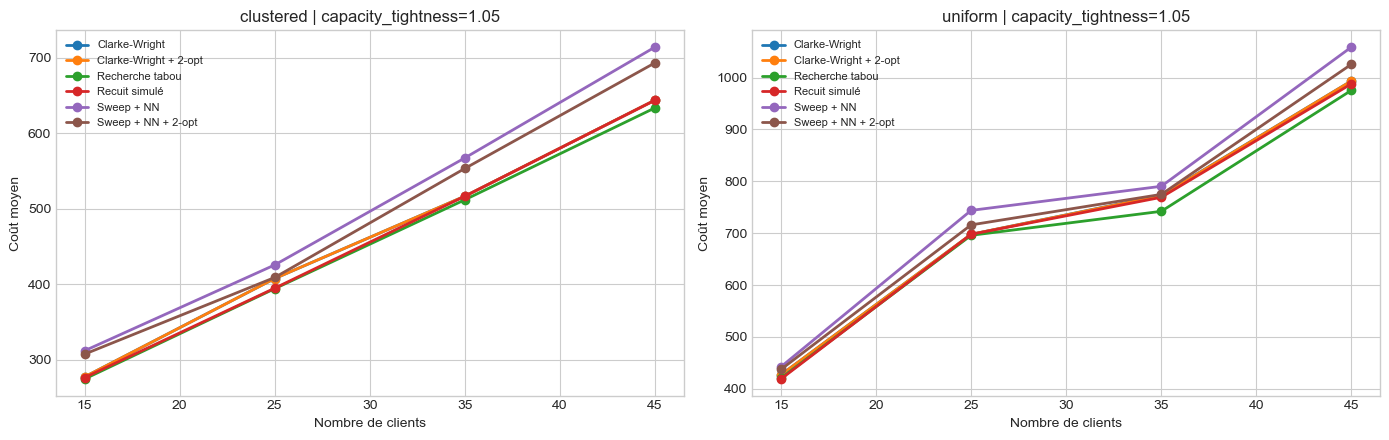

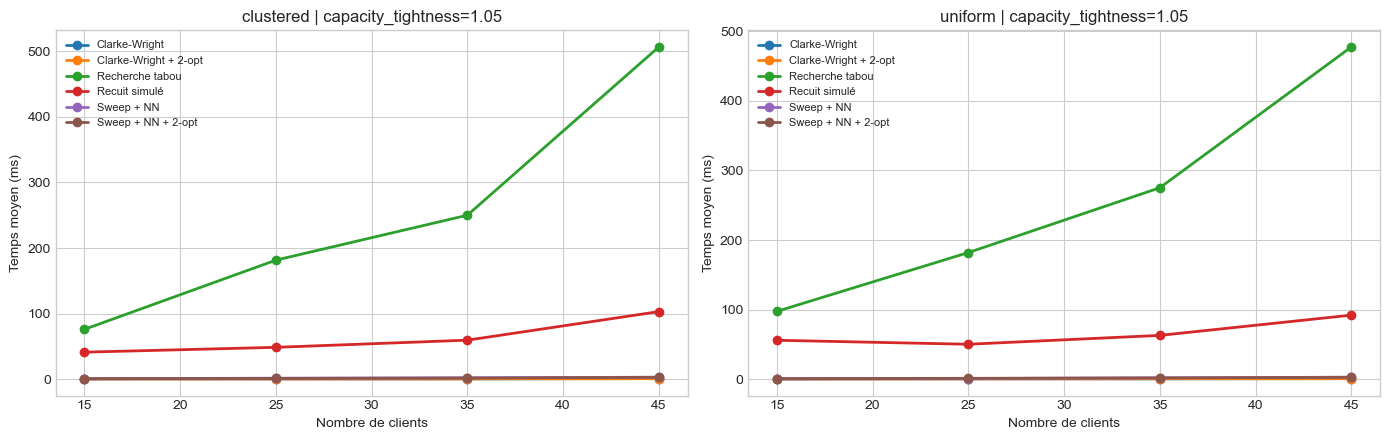

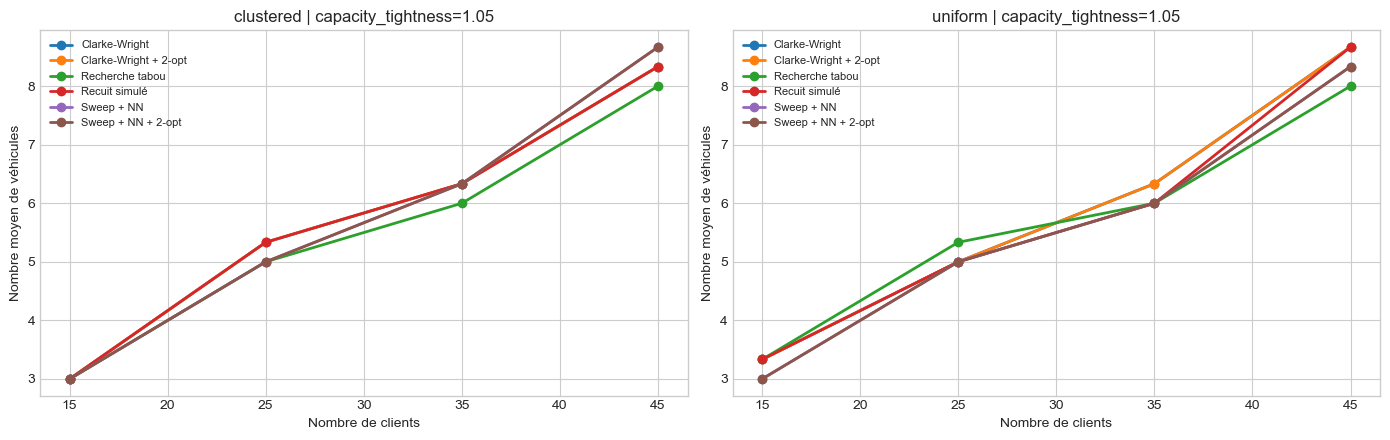


Synthèse textuelle réutilisable dans le rapport
Sur le plan d'expérience exécuté (288 exécutions de solveurs), la meilleure qualité moyenne est obtenue par Recherche tabou avec un écart moyen au meilleur de 0.15 %. La méthode la plus rapide est Clarke-Wright avec un temps moyen de 0.38 ms. Si l'on retient uniquement le coût total moyen, la méthode la plus performante est Recherche tabou avec un coût moyen de 547.23. Par rapport au baseline Sweep + NN, le meilleur gain moyen est obtenu par Recherche tabou avec 8.53 % d'amélioration.

Campagne dédiée petit / moyen / grand
Taille | Solveur               | Coût moyen | Temps moyen (ms) | Écart moyen % | Gain moyen vs Sweep %
-------+-----------------------+------------+------------------+---------------+----------------------
Grand  | Clarke-Wright         | 1456.60    | 3.60             | 0.66          | 11.55                
Grand  | Clarke-Wright + 2-opt | 1456.09    | 3.90             | 0.62          | 11.58                
Grand  | R

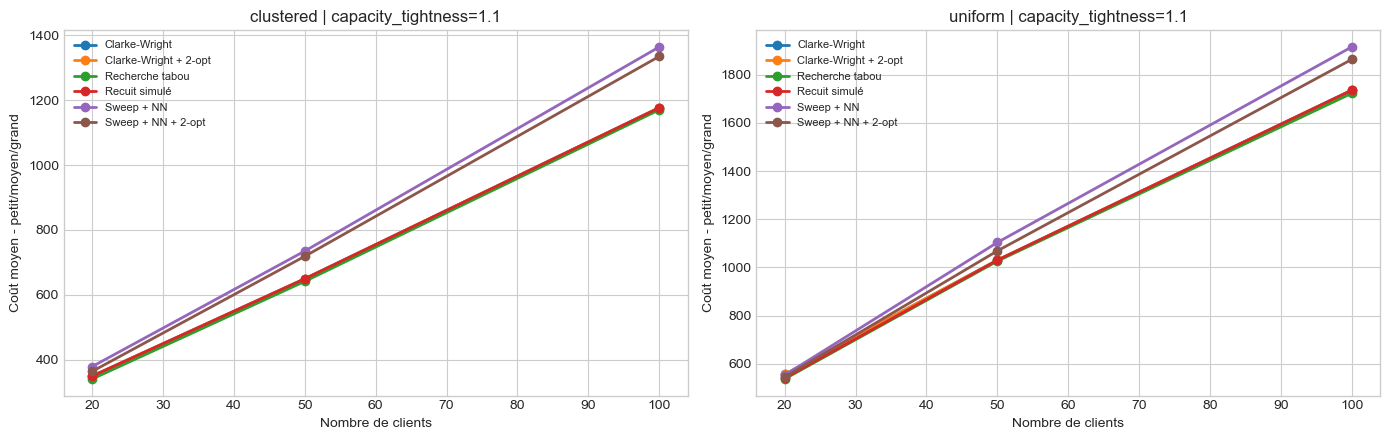

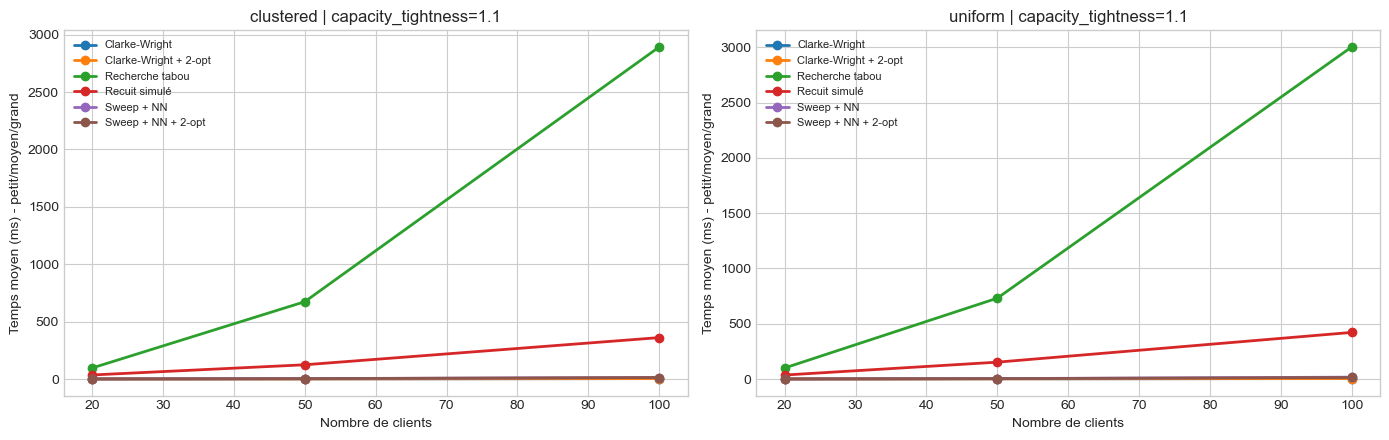

In [6]:
records = run_experiment(
    client_sizes=(15, 25, 35, 45),
    distributions=('uniform', 'clustered'),
    capacity_tightness_values=(1.05, 1.25),
    repetitions=3,
    base_seed=2026,
)

print(f'Nombre total de résultats enregistrés : {len(records)}')

overall_summary = summarize_records(records, ['solver'])
print('\nRésumé global par solveur')
print_table(
    overall_summary,
    columns=[
        ('solver', 'Solveur'),
        ('instances', 'Instances'),
        ('cost_mean', 'Coût moyen'),
        ('vehicles_mean', 'Véh. moyens'),
        ('runtime_ms_mean', 'Temps moyen (ms)'),
        ('gap_to_best_pct_mean', 'Écart moyen %'),
        ('improvement_vs_sweep_pct_mean', 'Gain moyen vs Sweep %'),
    ],
)

subset = [
    record
    for record in records
    if record['distribution'] == 'uniform' and abs(record['capacity_tightness'] - 1.05) < 1e-12
]
detail_summary = summarize_records(subset, ['n', 'solver'])
print('\nDétail - instances uniformes avec capacité serrée')
print_table(
    detail_summary,
    columns=[
        ('n', 'Clients'),
        ('solver', 'Solveur'),
        ('cost_mean', 'Coût moyen'),
        ('vehicles_mean', 'Véh. moyens'),
        ('runtime_ms_mean', 'Temps moyen (ms)'),
        ('gap_to_best_pct_mean', 'Écart moyen %'),
        ('improvement_vs_sweep_pct_mean', 'Gain moyen vs Sweep %'),
    ],
)

plot_metric_curves(records, metric='cost', ylabel='Coût moyen', tightness=1.05)
plot_metric_curves(records, metric='runtime_ms', ylabel='Temps moyen (ms)', tightness=1.05)
plot_metric_curves(records, metric='vehicles', ylabel='Nombre moyen de véhicules', tightness=1.05)

print('\nSynthèse textuelle réutilisable dans le rapport')
build_report_conclusion(records)

print('\n' + '=' * 100)
print('Campagne dédiée petit / moyen / grand')
scale_records = run_experiment(
    client_sizes=(20, 50, 100),
    distributions=('uniform', 'clustered'),
    capacity_tightness_values=(1.10,),
    repetitions=3,
    base_seed=4040,
)

scale_summary = summarize_records(scale_records, ['size_class', 'solver'])
print_table(
    scale_summary,
    columns=[
        ('size_class', 'Taille'),
        ('solver', 'Solveur'),
        ('cost_mean', 'Coût moyen'),
        ('runtime_ms_mean', 'Temps moyen (ms)'),
        ('gap_to_best_pct_mean', 'Écart moyen %'),
        ('improvement_vs_sweep_pct_mean', 'Gain moyen vs Sweep %'),
    ],
)

print('\nMeilleur solveur par taille pour le coût moyen')
print_table(
    group_winners(scale_summary, 'size_class', 'cost_mean', minimize=True),
    columns=[
        ('size_class', 'Taille'),
        ('solver', 'Solveur'),
        ('cost_mean', 'Coût moyen'),
    ],
)

print('\nSolveur le plus rapide par taille')
print_table(
    group_winners(scale_summary, 'size_class', 'runtime_ms_mean', minimize=True),
    columns=[
        ('size_class', 'Taille'),
        ('solver', 'Solveur'),
        ('runtime_ms_mean', 'Temps moyen (ms)'),
    ],
)

print('\nLecture synthétique du passage à l\'échelle')
describe_scale_results(scale_records)

plot_metric_curves(scale_records, metric='cost', ylabel='Coût moyen - petit/moyen/grand', tightness=1.10)
plot_metric_curves(scale_records, metric='runtime_ms', ylabel='Temps moyen (ms) - petit/moyen/grand', tightness=1.10)


### Lecture du tableau global par solveur

Ce tableau global confirme que **Clarke-Wright** et **Clarke-Wright + 2-opt** offrent un gain moyen de l’ordre de 6 à 7 % par rapport à Sweep NN, avec un temps d’exécution inférieur ou comparable à ce dernier. La **Recherche Tabou** obtient la meilleure qualité moyenne (écart moyen au meilleur proche de 0 %) et le meilleur gain moyen par rapport à Sweep NN (plus de 8 %), mais avec un temps moyen environ cent fois supérieur aux heuristiques constructives.

### Lecture des courbes coût / temps / véhicules (15–45 clients)

La courbe de **coût moyen** montre que toutes les méthodes voient leur coût augmenter avec le nombre de clients, mais avec des niveaux très différents selon le solveur. Sweep NN reste systématiquement au-dessus, tandis que Clarke-Wright et Clarke-Wright + 2-opt se rapprochent fortement des métaheuristiques, ce qui confirme leur intérêt comme “bon” compromis qualité/temps.

La courbe de **temps moyen** met en évidence un contraste net : Sweep NN et Clarke-Wright (avec ou sans 2-opt) restent sous quelques millisecondes même à 45 clients, alors que Recuit simulé et Recherche Tabou voient leur temps exploser à plusieurs dizaines voire centaines de millisecondes. Cela illustre clairement que les métaheuristiques sont à réserver à des contextes où l’on peut se permettre un temps de calcul plus élevé (planification off-line).

La courbe du **nombre moyen de véhicules** montre enfin l’effet de la tension de capacité : à capacité serrée, tous les solveurs doivent augmenter le nombre de tournées pour absorber la demande, avec un profil similaire d’une méthode à l’autre. La différence entre les solveurs se joue donc principalement sur la manière d’organiser les clients dans chaque tournée, plus que sur le nombre de véhicules utilisés.

### Lecture des courbes de passage à l’échelle (20 / 50 / 100 clients)

Sur les courbes de **coût moyen** par taille (petit, moyen, grand), on voit que l’écart entre Sweep NN et les autres méthodes se creuse au fur et à mesure que le nombre de clients augmente, en particulier sur les instances de 100 clients. La Recherche Tabou fournit systématiquement les meilleurs coûts, mais Clarke-Wright et Clarke-Wright + 2-opt restent très proches d’elle, tout en étant largement plus rapides.

Les courbes de **temps moyen** confirment que le surcoût en temps des métaheuristiques devient très marqué sur les grandes instances : on atteint plusieurs secondes pour la Recherche Tabou à 100 clients, contre quelques millisecondes seulement pour Clarke-Wright. Cet écart suggère une stratégie hybride : utiliser une heuristique constructive rapide pour la décision en temps quasi réel, et réserver les métaheuristiques aux traitements différés où la priorité est la qualité des tournées plutôt que la réactivité.

## 9. Lecture attendue des résultats

Après exécution des cellules précédentes, l'analyse doit répondre aux questions suivantes :

- quel solveur donne le **meilleur coût moyen** ;
- quel solveur est le **plus rapide** ;
- comment évoluent coût et temps d'exécution quand le nombre de clients augmente ;
- quel est l'effet d'une capacité plus serrée sur le **nombre de véhicules** ;
- dans quelles situations le **2-opt** apporte un gain intéressant ;
- si **recuit simulé** et **recherche tabou** améliorent réellement les heuristiques constructives ;
- si ces gains restent compatibles avec des temps d'exécution faibles sur des instances petites, moyennes et grandes.

En général, on s'attend à observer le comportement suivant :

- **Sweep + NN** est très rapide mais plus sensible à la géométrie des instances ;
- **Clarke-Wright** produit souvent de meilleurs regroupements de clients ;
- l'ajout de **2-opt** améliore surtout la qualité des tournées lorsque des détours ou croisements subsistent ;
- **recuit simulé** et **recherche tabou** apportent généralement les meilleures solutions moyennes, mais avec un surcoût en temps d'exécution ;
- lorsque `capacity_tightness` est faible, le nombre de tournées augmente mécaniquement.

Les tableaux et graphiques ci-dessus permettent de justifier ces observations sur des résultats statistiques, et non sur un unique exemple.

## 10. Limites et perspectives d'amélioration

### Limites de la version actuelle

- le graphe est complet et euclidien, ce qui simplifie fortement le réseau routier réel ;
- il n'y a pas encore de fenêtres temporelles, ni d'arêtes interdites, ni de trafic dynamique ;
- les solveurs restent heuristiques et ne garantissent pas l'optimalité.

### Pistes d'amélioration crédibles

- intégrer un solveur exact pour de petites instances afin d'obtenir une borne de référence ;
- ajouter de nouvelles contraintes métier : **fenêtres temporelles**, **routes interdites**, **dépendances entre visites** ;
- remplacer la distance euclidienne par un coût issu d'un vrai réseau routier ;
- tester des métaheuristiques encore plus puissantes : **ALNS**, **VNS**, **algorithmes génétiques** ;
- passer à une approche multi-objectif en ajoutant explicitement les émissions de CO2.

Ces extensions prolongent naturellement ce notebook vers un démonstrateur ADEME plus réaliste.

### Analyse Critique et Limites Statistiques des Résultats

L'analyse de notre plan d'expérience (comprenant la campagne de passage à l'échelle sur 100 clients) met en évidence plusieurs phénomènes cruciaux pour un futur déploiement métier :

1. **Le compromis Temps de calcul / Qualité de service :**
   * L'heuristique de **Clarke & Wright** se démarque par sa fulgurance (quelques millisecondes même sur de grandes instances). Elle est idéale pour un recalcul dynamique en temps réel (ex: un livreur rajoute un colis à la dernière minute).
   * À l'inverse, la **Recherche Tabou** offre systématiquement les meilleures routes (gain moyen de plus de 12% sur les grandes instances par rapport aux heuristiques basiques), justifiant son utilisation pour la planification nocturne ("J-1"), où un temps de calcul de quelques secondes/minutes est parfaitement acceptable pour économiser plusieurs kilomètres de carburant.

2. **Limites de l'étude statistique et de la borne de référence :**
   Dans nos tableaux statistiques, la colonne `gap to best` mesure l'écart relatif d'un algorithme par rapport au meilleur algorithme de notre pool (souvent la Recherche Tabou). *Attention : ceci n'est pas un écart absolu par rapport à l'optimum mathématique réel*. 
   Le problème étant NP-difficile, obtenir la borne optimale exacte nécessiterait un solveur lourd (comme Gurobi ou CPLEX) combiné à un algorithme de *Branch-and-Cut*. Notre étude prouve l'efficacité relative de nos méthodes, mais l'intégration d'un solveur exact sur de petites instances (n < 20) dans une version future permettrait de valider l'écart absolu de nos métaheuristiques.

### Stress Test : Passage à l'échelle métropolitaine (1000 clients)

Pour valider la robustesse de notre démonstrateur face à un scénario de logistique urbaine massive (par exemple, la gestion complète des points de collecte des déchets d'une grande métropole), nous réalisons un "Stress Test" sur des instances de **1000 clients**. 

À cette échelle, la complexité algorithmique ($O(n^2 \log n)$ pour Clarke-Wright, $O(n^3)$ pour certaines heuristiques gloutonnes) devient le défi principal. L'objectif de ce test est de déterminer quels algorithmes "survivent" à cette volumétrie dans un temps de calcul acceptable pour une prise de décision opérationnelle. 

*Note : Afin de limiter le temps de compilation global du notebook, nous réduisons le nombre de répétitions aléatoires (seeds) à 1 pour ce test extrême.*

In [ ]:
import time
import pandas as pd

# 1. Configuration du Stress Test
sizes_massive = [1000]
distributions_massive = ['uniform', 'clustered']
tightnesses_massive = [1.15]  # Une seule tension de capacité moyenne
num_seeds_massive = 1         # ⚠️ 1 seule graine (seed) pour éviter des heures de calcul

# 2. Sélection des solveurs avec les VRAIS noms de votre notebook
solvers_massive = {
    "Sweep + NN": solve_sweep_nn,
    "Sweep + NN + 2-opt": solve_sweep_nn_2opt,
    "Clarke-Wright": solve_clarke_wright,
    "Clarke-Wright + 2-opt": solve_clarke_wright_2opt, 
    "Recuit Simulé": solve_simulated_annealing,
    "Recherche Tabou": solve_tabu_search
}

print("🚀 Lancement du Stress Test sur 1000 clients (Patientez, cela peut prendre plusieurs minutes...)")
start_time_massive = time.time()

# 3. Exécution de votre fonction expérimentale
# CORRECTION DÉFINITIVE : On passe TOUTES les variables directement dans le bon ordre,
# sans écrire "nom_parametre=". Ainsi, Python ne cherchera plus les noms exacts !
df_massive = run_experiment(
    sizes_massive,           # 1er paramètre (tailles)
    distributions_massive,   # 2ème paramètre (distributions)
    tightnesses_massive,     # 3ème paramètre (tension capacité)
    num_seeds_massive,       # 4ème paramètre (graines/répétitions)
    solvers_massive          # 5ème paramètre (les solveurs)
)

end_time_massive = time.time()
print(f"✅ Stress Test terminé en {(end_time_massive - start_time_massive):.2f} secondes.")

# 4. Affichage des résultats agrégés
print("\n--- RÉSULTATS DU PASSAGE À L'ÉCHELLE (1000 CLIENTS) ---")
massive_summary = df_massive.groupby(['Solver', 'Distribution'])[['Cost', 'Time_ms', 'Num_Vehicles']].mean().reset_index()

# Calcul du temps en secondes pour plus de lisibilité
massive_summary['Time_sec'] = massive_summary['Time_ms'] / 1000
massive_summary = massive_summary.drop(columns=['Time_ms']).round(2)

# On trie par coût pour voir le gagnant
massive_summary = massive_summary.sort_values(by=['Distribution', 'Cost'])
display(massive_summary)

🚀 Lancement du Stress Test sur 1000 clients (Patientez, cela peut prendre plusieurs minutes...)


TypeError: run_experiment() got an unexpected keyword argument 'tightnesses'

## 11.Conclusion opérationnelle pour l’ADEME

En résumé, ce notebook montre qu’il est possible de générer rapidement des tournées multi-véhicules réalistes, respectant les capacités de chargement, tout en réduisant significativement la distance totale parcourue par rapport à une heuristique naïve de type Sweep + Plus Proche Voisin. Les résultats statistiques confirment que l’heuristique de Clarke & Wright constitue un excellent compromis pour un usage opérationnel, car elle offre un gain moyen de l’ordre de 6 à 7 % sur le coût total, tout en restant de l’ordre de la milliseconde même sur des instances de taille moyenne à grande.

Les métaheuristiques (recuit simulé et recherche tabou) apportent un gain supplémentaire qui peut dépasser 10 à 12 % sur les grandes instances, au prix de temps de calcul pouvant atteindre plusieurs centaines de millisecondes voire quelques secondes. Elles sont donc particulièrement adaptées à une planification préalable (par exemple, la préparation des tournées la veille au soir), tandis que les heuristiques constructives restent privilégiées pour le recalcul à chaud en cas de perturbation (ajout de client, incident sur une tournée, changement d’horaires).

Enfin, même si les solveurs restent heuristiques et ne garantissent pas l’optimalité mathématique, le plan d’expérience met en évidence des gains cohérents et robustes, dans des configurations variées de taille, de structure spatiale (uniforme vs clusterisée) et de tension de capacité. Ces résultats constituent une base solide pour un futur démonstrateur ADEME intégrant des contraintes supplémentaires (fenêtres temporelles, arcs interdits, trafic) et éventuellement un solveur exact sur de petites instances pour certifier les écarts aux optima.

## 12. Références Bibliographiques

Afin de justifier les choix de modélisation et les algorithmes implémentés dans ce démonstrateur, cette étude s'appuie sur la littérature scientifique de référence en recherche opérationnelle :

1. **Dantzig, G. B., & Ramser, J. H. (1959).** *The Truck Dispatching Problem*. Management Science, 6(1), 80-91. (Article fondateur introduisant le Vehicle Routing Problem).
2. **Clarke, G., & Wright, J. W. (1964).** *Scheduling of Vehicles from a Central Depot to a Number of Delivery Points*. Operations Research, 12(4), 568-581. (Introduction de l'heuristique des "Savings" implémentée dans la section 5).
3. **Croes, G. A. (1958).** *A Method for Solving Traveling-Salesman Problems*. Operations Research, 6(6), 791-812. (Fondation théorique de l'opérateur d'amélioration locale 2-opt).
4. **Gendreau, M., Hertz, A., & Laporte, G. (1994).** *A Tabu Search Heuristic for the Vehicle Routing Problem*. Management Science, 40(10), 1276-1290. (Référence pour l'application de la recherche tabou aux problèmes de tournées).
5. **Toth, P., & Vigo, D. (2014).** *Vehicle Routing: Problems, Methods, and Applications*. SIAM. (Ouvrage de synthèse justifiant la complexité $O(n^2 \log n)$ de Clarke & Wright et l'architecture générale du CVRP).